# Level 2 — ResNet-50 with ImageNet pretraining (UCM **multilabel**)

Deep Learning project, GRS-34806 / FTE-35306. Fine-tune ResNet-50 on the
UCM multilabel annotations (17 labels per image, from `LandUse_Multilabeled.txt`).
Loss: `BCEWithLogitsLoss`. Metrics: macro-F1, macro accuracy, macro mAP.

## 1. Mount Drive, clone repo, install dependencies

In [1]:
!git config --global user.email "gabriel.castro.b@pucv.cl"

In [2]:
!git config --global user.name "gabrielcastrob"

In [3]:
# Install dependencies if not already installed
!pip install -q torch torchvision lightning matplotlib seaborn pathlib scikit-learn scikit-image torchmetrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 68.2 MB/s eta 0:00:00


## 2. Download UCM dataset (skips if already in Drive repo)

In [6]:
# Download the UCMerced Land Use dataset if not already present.
# The dataset will be saved in the 'ucmdata' directory.

import os
import zipfile
import subprocess
import shutil
from pathlib import Path

PROJECT_DIR = Path.cwd()  # ← captura el directorio de trabajo actual

if not os.path.exists('ucmdata'):
    print("Cloning ucmdata repo and extracting images...")
    subprocess.run(['git', 'clone', 'https://git.wur.nl/lobry001/ucmdata.git'])
    os.chdir('ucmdata')

    with zipfile.ZipFile('UCMerced_LandUse.zip', 'r') as zip_ref:
        zip_ref.extractall('UCMImages')

    shutil.move('UCMImages/UCMerced_LandUse/Images', '.')
    shutil.rmtree('UCMImages')
    if os.path.exists('README.md'): os.remove('README.md')
    if os.path.exists('UCMerced_LandUse.zip'): os.remove('UCMerced_LandUse.zip')
    os.chdir(PROJECT_DIR)
    print("Dataset extracted into ucmdata/")
else:
    print("ucmdata/ already present, skipping download.")

UCM_ROOT = Path("ucmdata/Images")
n_classes = len([p for p in UCM_ROOT.iterdir() if p.is_dir()])
n_images = sum(len(list(p.glob("*.tif"))) for p in UCM_ROOT.iterdir() if p.is_dir())
print(f"UCM_ROOT: {UCM_ROOT.resolve()}")
print(f"Class folders: {n_classes}  |  Total images: {n_images}")

Cloning ucmdata repo and extracting images...
Dataset extracted into ucmdata/
UCM_ROOT: /content/ucmdata/ucmdata/Images
Class folders: 21  |  Total images: 2100


## 3. Imports

In [7]:
import random, shutil, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as tvm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
import torchmetrics

L.seed_everything(42, workers=True)
DEVICE = "gpu" if torch.cuda.is_available() else "cpu"
print("Accelerator:", DEVICE)
if DEVICE == "gpu":
    print("GPU:", torch.cuda.get_device_name(0))

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Accelerator: gpu
GPU: Tesla T4


## 4. Multilabel classes and dataset

In [8]:
import re

MULTILABEL_TXT = Path("ucmdata/LandUse_Multilabeled.txt")

def parse_multilabels(label_path):
    """Parse UCM multilabel TSV/whitespace file into (class_names, {image_stem: label_vector})."""
    with open(label_path) as f:
        lines = [ln.rstrip("\n") for ln in f if ln.strip()]
    header = re.split(r"\s+", lines[0].strip())
    # First column is "IMAGE\LABEL" (or similar), the rest are class names
    class_names = header[1:]
    labels = {}
    for ln in lines[1:]:
        parts = re.split(r"\s+", ln.strip())
        stem = parts[0]
        vec = np.array([int(x) for x in parts[1:]], dtype=np.float32)
        assert len(vec) == len(class_names), f"Row {stem} has {len(vec)} labels, expected {len(class_names)}"
        labels[stem] = vec
    return class_names, labels

import numpy as np
ML_CLASSES, ML_LABELS = parse_multilabels(MULTILABEL_TXT)
NUM_CLASSES = len(ML_CLASSES)
print(f"Multilabel classes ({NUM_CLASSES}): {ML_CLASSES}")
print(f"Labeled images: {len(ML_LABELS)}")

class UCMMultilabelDataset(Dataset):
    """UCM multilabel dataset. Each sample is (PIL_image, float_label_vector of length NUM_CLASSES)."""
    def __init__(self, root, samples, transform=None):
        self.root = Path(root)
        self.samples = samples  # list of (rel_path, label_vector np.float32)
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        rel_path, label = self.samples[idx]
        img = Image.open(self.root / rel_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, torch.from_numpy(label)

Multilabel classes (17): ['airplane', 'bare-soil', 'buildings', 'cars', 'chaparral', 'court', 'dock', 'field', 'grass', 'mobile-home', 'pavement', 'sand', 'sea', 'ship', 'tanks', 'trees', 'water']
Labeled images: 2100


## 5. Build train/val/test split

Random 80/10/10 split with fixed seed (stratifying a multilabel problem
by a single class is not meaningful; a random split is standard here).

In [10]:
# Pair image files with their multilabel vector
samples = []
missing = 0
for class_folder in sorted(os.listdir(UCM_ROOT)):
    class_dir = UCM_ROOT / class_folder
    if not class_dir.is_dir():
        continue
    for fname in sorted(os.listdir(class_dir)):
        if fname.lower().endswith(".tif"):
            stem = Path(fname).stem  # e.g. "agricultural00"
            if stem in ML_LABELS:
                samples.append((f"{class_folder}/{fname}", ML_LABELS[stem]))
            else:
                missing += 1

print(f"Total multilabel samples: {len(samples)}  (missing labels: {missing})")

rng = np.random.default_rng(42)
idx = np.arange(len(samples))
rng.shuffle(idx)
n = len(idx)
n_test = int(0.10 * n)
n_val  = int(0.10 * n)
test_idx  = idx[:n_test]
val_idx   = idx[n_test : n_test + n_val]
train_idx = idx[n_test + n_val:]

train_items = [samples[i] for i in train_idx]
val_items   = [samples[i] for i in val_idx]
test_items  = [samples[i] for i in test_idx]
print(f"train={len(train_items)}  val={len(val_items)}  test={len(test_items)}")

# Quick sanity check: label cardinality distribution
cards = np.array([s[1].sum() for s in samples])
print(f"Labels per image -- mean: {cards.mean():.2f}, min: {int(cards.min())}, max: {int(cards.max())}")

Total multilabel samples: 2100  (missing labels: 0)
train=1680  val=210  test=210
Labels per image -- mean: 3.33, min: 1, max: 7


## 6. Transforms and DataLoaders

In [11]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = UCMMultilabelDataset(UCM_ROOT, train_items, transform=train_tf)
val_ds   = UCMMultilabelDataset(UCM_ROOT, val_items,   transform=eval_tf)
test_ds  = UCMMultilabelDataset(UCM_ROOT, test_items,  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

print(f"train batches: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

train batches: 53  val: 7  test: 7


## 7. Model: ResNet-50 pretrained on ImageNet (multilabel head)

The 1000-class ImageNet head is replaced by a linear layer with `NUM_CLASSES`
output logits — **no softmax**, since each label is independent and we use
`BCEWithLogitsLoss`. Full fine-tuning (all layers trainable).

In [12]:
def build_resnet50(num_classes):
    weights = tvm.ResNet50_Weights.IMAGENET1K_V2
    model = tvm.resnet50(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

backbone = build_resnet50(num_classes=NUM_CLASSES)
n_params = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
print(f"ResNet-50 trainable parameters: {n_params:,}  |  output logits: {NUM_CLASSES}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 127MB/s] 


ResNet-50 trainable parameters: 23,542,865  |  output logits: 17


## 8. LightningModule (multilabel)

`BCEWithLogitsLoss` on per-class logits. Metrics: macro F1, macro accuracy
(per-label binary accuracy averaged over classes), and macro mAP.
Optimizer: AdamW with cosine LR schedule.

In [13]:
class LitResNetMultilabel(L.LightningModule):
    def __init__(self, model, num_classes, lr=1e-4, weight_decay=1e-4,
                 max_epochs=15, threshold=0.5):
        super().__init__()
        self.save_hyperparameters(ignore=["model"])
        self.model = model
        self.criterion = nn.BCEWithLogitsLoss()
        self.threshold = threshold

        mk = dict(task="multilabel", num_labels=num_classes, threshold=threshold)
        self.train_f1 = torchmetrics.F1Score(average="macro", **mk)
        self.val_f1   = torchmetrics.F1Score(average="macro", **mk)
        self.test_f1  = torchmetrics.F1Score(average="macro", **mk)
        self.val_acc  = torchmetrics.Accuracy(average="macro", **mk)
        self.test_acc = torchmetrics.Accuracy(average="macro", **mk)
        self.val_map  = torchmetrics.AveragePrecision(task="multilabel", num_labels=num_classes, average="macro")
        self.test_map = torchmetrics.AveragePrecision(task="multilabel", num_labels=num_classes, average="macro")

    def forward(self, x):
        return self.model(x)

    def _step(self, batch):
        imgs, labels = batch          # labels: float tensor (B, C)
        logits = self(imgs)
        loss = self.criterion(logits, labels)
        return loss, logits, labels

    def training_step(self, batch, batch_idx):
        loss, logits, labels = self._step(batch)
        self.train_f1.update(logits, labels.int())
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_f1",   self.train_f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, logits, labels = self._step(batch)
        self.val_f1.update(logits, labels.int())
        self.val_acc.update(logits, labels.int())
        self.val_map.update(logits, labels.int())
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_f1",   self.val_f1,  on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_acc",  self.val_acc, on_step=False, on_epoch=True)
        self.log("val_map",  self.val_map, on_step=False, on_epoch=True)

    def test_step(self, batch, batch_idx):
        loss, logits, labels = self._step(batch)
        self.test_f1.update(logits, labels.int())
        self.test_acc.update(logits, labels.int())
        self.test_map.update(logits, labels.int())
        self.log("test_loss", loss, on_step=False, on_epoch=True)
        self.log("test_f1",   self.test_f1,  on_step=False, on_epoch=True)
        self.log("test_acc",  self.test_acc, on_step=False, on_epoch=True)
        self.log("test_map",  self.test_map, on_step=False, on_epoch=True)

    def predict_step(self, batch, batch_idx):
        imgs, labels = batch
        logits = self(imgs)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= self.threshold).int()
        return {"probs": probs, "preds": preds, "labels": labels.int()}

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(),
                                      lr=self.hparams.lr,
                                      weight_decay=self.hparams.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.hparams.max_epochs)
        return [optimizer], [scheduler]

## 9. Train

In [14]:
MAX_EPOCHS = 30
LR = 1e-4

lit_model = LitResNetMultilabel(model=backbone, num_classes=NUM_CLASSES,
                                lr=LR, weight_decay=1e-4, max_epochs=MAX_EPOCHS)
# validation set early stopping based on val_f1, save best model weights only. We will load these best weights later for testing and analysis.
checkpoint_cb = ModelCheckpoint(
    dirpath="outputs/checkpoints",
    filename="resnet50-multilabel-best-{epoch:02d}-{val_f1:.4f}",
    monitor="val_f1", mode="max", save_top_k=1, save_weights_only=True,
)
csv_logger = CSVLogger(save_dir="outputs/logs", name="resnet50_multilabel")

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",
    devices="auto",
    callbacks=[checkpoint_cb],
    logger=csv_logger,
    log_every_n_steps=10,
)
trainer.fit(lit_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet                     │ 23.5 M │ train │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss          │      0 │ train │     0 │
│ 2 │ train_f1  │ MultilabelF1Score          │      0 │ train │     0 │
│ 3 │ val_f1    │ MultilabelF1Score          │      0 │ train │     0 │
│ 4 │ test_f1   │ MultilabelF1Score          │      0 │ train │     0 │
│ 5 │ val_acc   │ MultilabelAccuracy         │      0 │ train │     0 │
│ 6 │ test_acc  │ MultilabelAccuracy         │      0 │ train │     0 │
│ 7 │ val_map   │ MultilabelAveragePrecision │      0 │ train │     0 │
│ 8 │ test_map  │ MultilabelAveragePrecision │      0 │ train │     0 │
└───┴───────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 23.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 23.5 M                                                                                               
Total estimated model params size (MB): 94                                                                         
Modules in train mode: 159                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


## 10. Test on the held-out set

In [15]:
# Evaluate using the best checkpoint
trainer.test(lit_model, dataloaders=test_loader, ckpt_path="best")

best_path = checkpoint_cb.best_model_path
print(f"Best checkpoint: {best_path}")
lit_model = LitResNetMultilabel.load_from_checkpoint(best_path, model=lit_model.model)

# Collect probs, preds and ground-truth for downstream analysis
preds_out = trainer.predict(lit_model, dataloaders=test_loader)
test_probs  = torch.cat([b["probs"]  for b in preds_out], dim=0).cpu().numpy()
test_preds  = torch.cat([b["preds"]  for b in preds_out], dim=0).cpu().numpy()
test_labels = torch.cat([b["labels"] for b in preds_out], dim=0).cpu().numpy()

from sklearn.metrics import f1_score, average_precision_score, hamming_loss

macro_f1  = f1_score(test_labels, test_preds, average="macro",  zero_division=0)
micro_f1  = f1_score(test_labels, test_preds, average="micro",  zero_division=0)
samples_f1 = f1_score(test_labels, test_preds, average="samples", zero_division=0)
macro_map = average_precision_score(test_labels, test_probs, average="macro")
hamming   = hamming_loss(test_labels, test_preds)
subset_acc = (test_preds == test_labels).all(axis=1).mean()  # exact-match

print(f"\nTest macro F1   : {macro_f1:.4f}")
print(f"Test micro F1   : {micro_f1:.4f}")
print(f"Test samples F1 : {samples_f1:.4f}")
print(f"Test macro mAP  : {macro_map:.4f}")
print(f"Hamming loss    : {hamming:.4f}")
print(f"Exact-match acc : {subset_acc:.4f}")

INFO: Restoring states from the checkpoint path at /content/ucmdata/outputs/checkpoints/resnet50-multilabel-best-epoch=13-val_f1=0.9416.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/ucmdata/outputs/checkpoints/resnet50-multilabel-best-epoch=13-val_f1=0.9416.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/ucmdata/outputs/checkpoints/resnet50-multilabel-best-epoch=13-val_f1=0.9416.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/ucmdata/outputs/checkpoints/resnet50-multilabel-best-epoch=13-val_f1=0.9416.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9621847867965698     │
│          test_f1          │    0.9452732801437378     │
│         test_loss         │    0.10797031223773956    │
│         test_map          │    0.9774800539016724     │
└───────────────────────────┴───────────────────────────┘

Best checkpoint: /content/ucmdata/outputs/checkpoints/resnet50-multilabel-best-epoch=13-val_f1=0.9416.ckpt


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


Test macro F1   : 0.9453
Test micro F1   : 0.9046
Test samples F1 : 0.9163
Test macro mAP  : 0.9775
Hamming loss    : 0.0378
Exact-match acc : 0.5571


## 11. Plots — learning curves and per-class F1

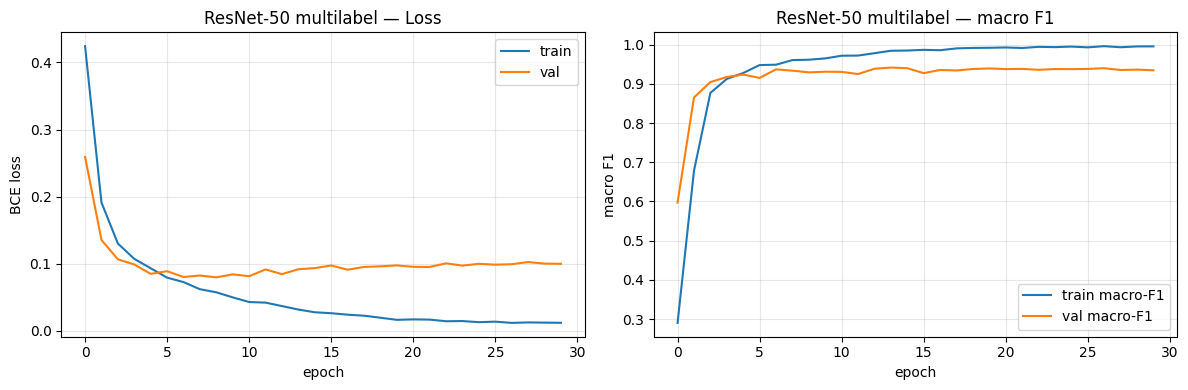

In [16]:
metrics_csv = Path(csv_logger.log_dir) / "metrics.csv"
df = pd.read_csv(metrics_csv)
epoch_df = df.groupby("epoch").mean(numeric_only=True).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if "train_loss" in epoch_df:
    axes[0].plot(epoch_df["epoch"], epoch_df["train_loss"], label="train")
if "val_loss" in epoch_df:
    axes[0].plot(epoch_df["epoch"], epoch_df["val_loss"], label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title("ResNet-50 multilabel — Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

if "train_f1" in epoch_df:
    axes[1].plot(epoch_df["epoch"], epoch_df["train_f1"], label="train macro-F1")
if "val_f1" in epoch_df:
    axes[1].plot(epoch_df["epoch"], epoch_df["val_f1"], label="val macro-F1")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("macro F1")
axes[1].set_title("ResNet-50 multilabel — macro F1"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
Path("outputs").mkdir(exist_ok=True)
plt.savefig("outputs/resnet50_multilabel_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

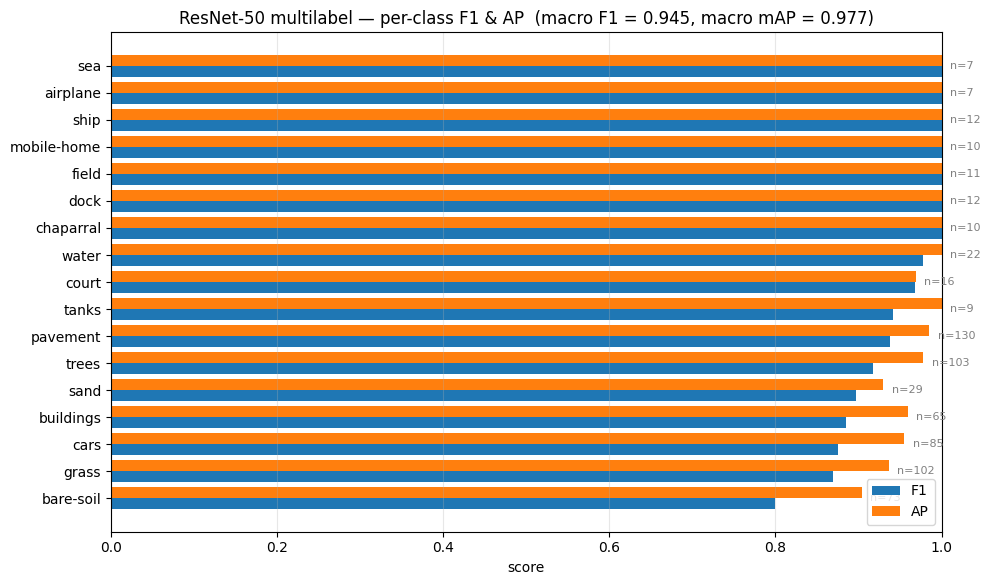

      class  positives     F1     AP
   airplane          7 1.0000 1.0000
  chaparral         10 1.0000 1.0000
       dock         12 1.0000 1.0000
      field         11 1.0000 1.0000
mobile-home         10 1.0000 1.0000
        sea          7 1.0000 1.0000
       ship         12 1.0000 1.0000
      water         22 0.9778 1.0000
      court         16 0.9677 0.9688
      tanks          9 0.9412 1.0000
   pavement        130 0.9385 0.9853
      trees        103 0.9179 0.9782
       sand         29 0.8966 0.9301
  buildings         65 0.8855 0.9594
       cars         85 0.8750 0.9554
      grass        102 0.8696 0.9363
  bare-soil         73 0.8000 0.9037

All outputs saved to: /content/ucmdata/outputs


In [17]:
per_class_f1 = f1_score(test_labels, test_preds, average=None, zero_division=0)
per_class_ap = average_precision_score(test_labels, test_probs, average=None)
positives    = test_labels.sum(axis=0).astype(int)

order = np.argsort(per_class_f1)   # ascending, so weakest classes show first
classes_sorted = [ML_CLASSES[i] for i in order]
f1_sorted  = per_class_f1[order]
ap_sorted  = per_class_ap[order]
pos_sorted = positives[order]

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * NUM_CLASSES)))
y = np.arange(NUM_CLASSES)
ax.barh(y - 0.2, f1_sorted, height=0.4, label="F1")
ax.barh(y + 0.2, ap_sorted, height=0.4, label="AP")
ax.set_yticks(y); ax.set_yticklabels(classes_sorted)
ax.set_xlim(0, 1)
ax.set_xlabel("score")
ax.set_title(f"ResNet-50 multilabel — per-class F1 & AP  (macro F1 = {macro_f1:.3f}, macro mAP = {macro_map:.3f})")
for i, (f, a, p) in enumerate(zip(f1_sorted, ap_sorted, pos_sorted)):
    ax.text(max(f, a) + 0.01, i, f"n={p}", va="center", fontsize=8, color="gray")
ax.legend(loc="lower right"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/resnet50_multilabel_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

# Per-class summary table
summary = pd.DataFrame({
    "class": ML_CLASSES,
    "positives": positives,
    "F1":  per_class_f1.round(4),
    "AP":  per_class_ap.round(4),
}).sort_values("F1", ascending=False)
print(summary.to_string(index=False))
summary.to_csv("outputs/resnet50_multilabel_per_class.csv", index=False)
print("\nAll outputs saved to:", Path("outputs").resolve())

In [1]:
# Grid of test images with ground-truth vs predicted labels
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

N_SHOW = 9                       # 3x3 grid
COLS = 3
ROWS = (N_SHOW + COLS - 1) // COLS

# Pick a mix: a few "easy" (all correct), a few with at least one mistake.
errors_per_sample = (test_preds != test_labels).sum(axis=1)
correct_idx  = np.where(errors_per_sample == 0)[0]
wrong_idx    = np.where(errors_per_sample > 0)[0]

rng_show = np.random.default_rng(0)
n_correct = min(N_SHOW // 2, len(correct_idx))
n_wrong   = N_SHOW - n_correct
chosen = np.concatenate([
    rng_show.choice(correct_idx, n_correct, replace=False),
    rng_show.choice(wrong_idx,   n_wrong,   replace=False),
])
rng_show.shuffle(chosen)

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 4.5, ROWS * 5.2))
axes = axes.flatten()

for ax, sample_i in zip(axes, chosen):
    rel_path, _ = test_items[sample_i]
    img = Image.open(UCM_ROOT / rel_path).convert("RGB")
    ax.imshow(img)
    ax.axis("off")

    gt   = test_labels[sample_i].astype(bool)
    pred = test_preds[sample_i].astype(bool)
    probs = test_probs[sample_i]

    tp = gt &  pred
    fp = ~gt &  pred       # predicted but not in GT
    fn = gt  & ~pred       # in GT but missed

    # Header: filename + TP/FP/FN counts
    fname = Path(rel_path).name
    ax.set_title(f"{fname}\nTP={tp.sum()}  FP={fp.sum()}  FN={fn.sum()}",
                 fontsize=10, loc="left")

    # Build a colored caption beneath the image
    lines = []
    for i in np.where(tp)[0]:
        lines.append(("green",  f"✓ {ML_CLASSES[i]}  ({probs[i]:.2f})"))
    for i in np.where(fn)[0]:
        lines.append(("red",    f"✗ {ML_CLASSES[i]}  ({probs[i]:.2f})  [missed]"))
    for i in np.where(fp)[0]:
        lines.append(("orange", f"+ {ML_CLASSES[i]}  ({probs[i]:.2f})  [extra]"))

    # Render the colored lines stacked under the image
    for j, (color, text) in enumerate(lines):
        ax.text(0.0, -0.04 - 0.06 * j, text, transform=ax.transAxes,
                fontsize=9, color=color, va="top", ha="left", family="monospace")

# Hide any unused axes
for ax in axes[len(chosen):]:
    ax.axis("off")

# Legend
legend_handles = [
    mpatches.Patch(color="green",  label="TP — correctly predicted"),
    mpatches.Patch(color="red",    label="FN — missed (in GT, not predicted)"),
    mpatches.Patch(color="orange", label="FP — extra (predicted, not in GT)"),
]
fig.legend(handles=legend_handles, loc="upper center",
           bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

plt.tight_layout()
Path("outputs").mkdir(exist_ok=True)
plt.savefig("outputs/resnet50_multilabel_predictions_grid.png",
            dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'test_preds' is not defined

In [19]:
!pip install -q torch torchvision lightning matplotlib seaborn pathlib scikit-learn scikit-image torchmetrics iterative-stratification wandb

In [ ]:
import wandb
wandb.login()   # te pide tu API key — la copias de https://wandb.a1i/authorize

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
